# 第24篇｜关系探索：散点图 / 气泡图 / 相关热力图

> 这是「数据分析从入门到精通」系列的第 24 篇。分布看完了，这篇来看"关系"——变量之间有没有关联？散点图、气泡图、相关热力图，三件套搞定关系探索，是做特征分析和建模选特征的必备技能。

---

嗨，我是小荷～

上一篇我们探索了"单个变量的分布"，今天来研究**两个或多个变量之间的关系**。

「广告投入越多，销售额就越高吗？」「用户年龄和客单价有关系吗？」「哪个因素最影响退款率？」

要回答这类问题，就需要关系探索图表。散点图是起点，气泡图加第三维度，相关热力图一次看全局。

---

## 一、散点图（Scatter Plot）

### 基础散点图

散点图用于展示两个变量的关系，来画一个：


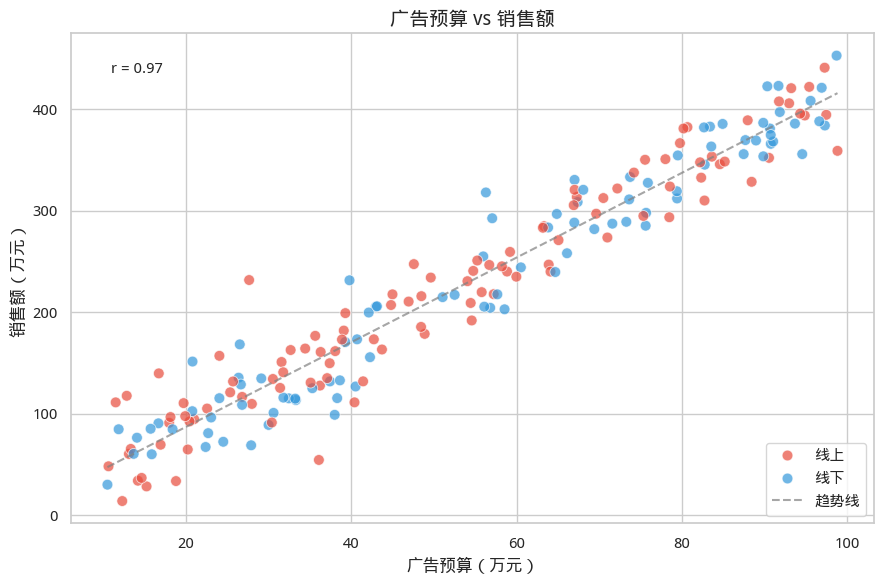

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

np.random.seed(42)
n = 200
ad_budget  = np.random.uniform(10, 100, n)
sales      = ad_budget * 4.2 + np.random.normal(0, 30, n)
channel    = np.random.choice(['线上', '线下'], n)

df = pd.DataFrame({'广告预算': ad_budget, '销售额': sales, '渠道': channel})

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=df, x='广告预算', y='销售额', hue='渠道',
                 palette=['#E74C3C', '#3498DB'],
                 alpha=0.7, s=60, ax=ax)

# 添加总体趋势线
z = np.polyfit(df['广告预算'], df['销售额'], 1)
p = np.poly1d(z)
x_trend = np.linspace(df['广告预算'].min(), df['广告预算'].max(), 100)
ax.plot(x_trend, p(x_trend), '--', color='gray', linewidth=1.5, alpha=0.7, label='趋势线')

corr = df['广告预算'].corr(df['销售额'])
ax.text(0.05, 0.92, f'r = {corr:.2f}', transform=ax.transAxes,
         fontsize=11, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_title('广告预算 vs 销售额', fontsize=14, fontweight='bold')
ax.set_xlabel('广告预算（万元）')
ax.set_ylabel('销售额（万元）')
ax.legend()
plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.tight_layout()
plt.show()


### 用 sns.regplot 直接加回归线

来看看用 sns.regplot 直接加回归线怎么实现：


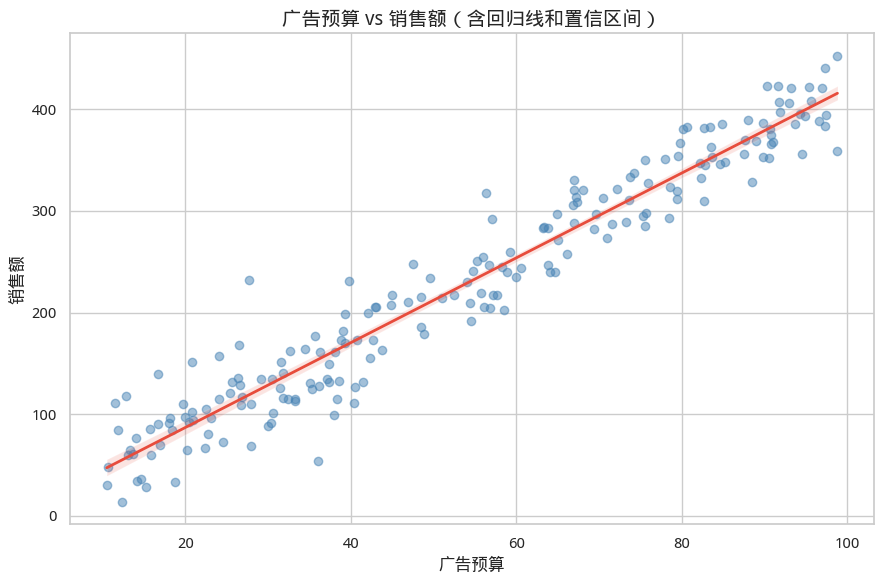

In [3]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(data=df, x='广告预算', y='销售额',
             scatter_kws={'alpha': 0.5, 'color': 'steelblue'},
             line_kws={'color': '#E74C3C', 'linewidth': 2},
             ci=95, ax=ax)   # ci=95 显示95%置信区间

ax.set_title('广告预算 vs 销售额（含回归线和置信区间）', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---

## 二、气泡图（Bubble Chart）

气泡图 = 散点图 + 第三个变量（用气泡大小/颜色编码）：


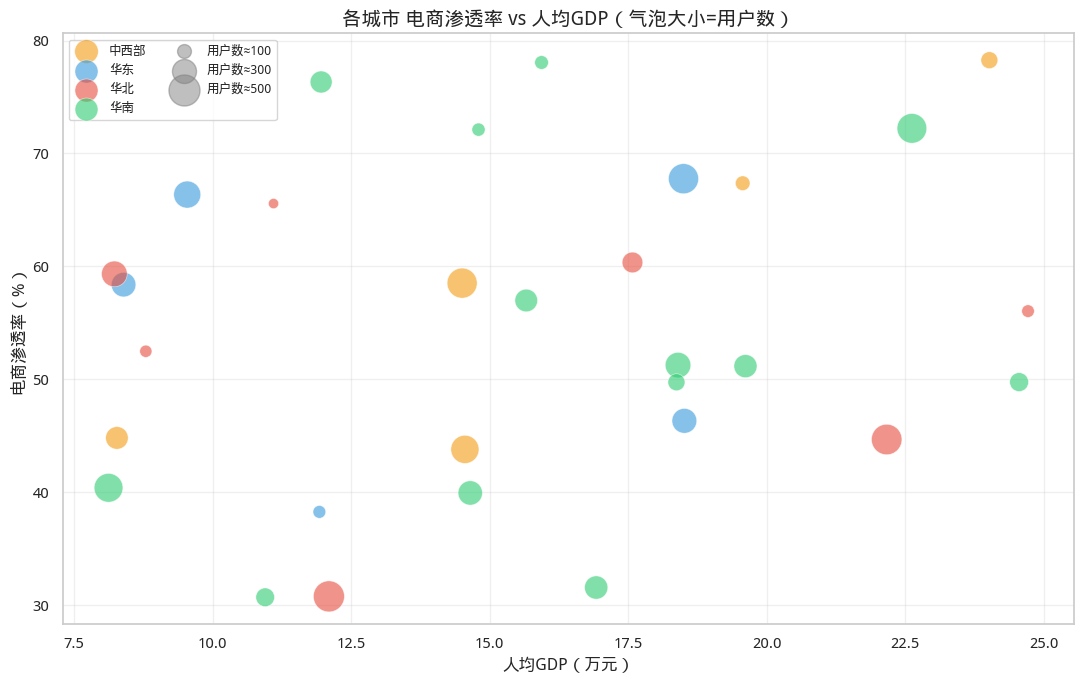

In [4]:
np.random.seed(42)
n = 30
cities = ['北京', '上海', '广州', '深圳', '杭州', '成都', '武汉',
          '南京', '重庆', '西安', '苏州', '天津', '合肥', '厦门',
          '长沙'] * 2

df_city = pd.DataFrame({
    '城市':   np.random.choice(cities, n),
    '人均GDP': np.random.uniform(8, 25, n),
    '电商渗透率': np.random.uniform(30, 80, n),
    '用户数': np.random.randint(50, 500, n),
    '区域':  np.random.choice(['华北', '华东', '华南', '中西部'], n)
})

fig, ax = plt.subplots(figsize=(11, 7))

region_colors = {'华北': '#E74C3C', '华东': '#3498DB', '华南': '#2ECC71', '中西部': '#F39C12'}
for region, group in df_city.groupby('区域'):
    sc = ax.scatter(
        group['人均GDP'],
        group['电商渗透率'],
        s=group['用户数'],                      # 气泡大小
        color=region_colors[region],
        alpha=0.6,
        label=region,
        edgecolors='white', linewidth=0.5
    )

# 图例中加上气泡大小说明
for size in [100, 300, 500]:
    ax.scatter([], [], s=size, color='gray', alpha=0.5, label=f'用户数≈{size}')

ax.set_xlabel('人均GDP（万元）', fontsize=12)
ax.set_ylabel('电商渗透率（%）', fontsize=12)
ax.set_title('各城市 电商渗透率 vs 人均GDP（气泡大小=用户数）',
              fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---

## 三、相关热力图（Correlation Heatmap）

相关热力图是**多变量关系**的一览图，一张图看所有变量两两之间的相关性：


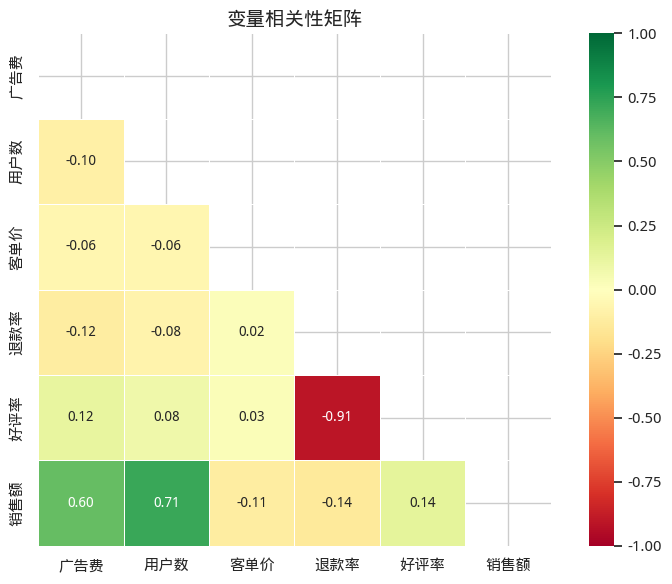

与销售额的相关性排名：
用户数    0.711667
广告费    0.596461
好评率    0.138039
退款率   -0.136974
客单价   -0.112939
Name: 销售额, dtype: float64


In [5]:
np.random.seed(42)
n = 300

df_corr = pd.DataFrame({
    '广告费':  np.random.uniform(10, 100, n),
    '用户数':  np.random.uniform(100, 1000, n),
    '客单价':  np.random.lognormal(6, 0.5, n),
    '退款率':  np.random.uniform(0, 0.15, n),
    '好评率':  np.random.uniform(0.7, 1.0, n)
})
# 构造相关性
df_corr['销售额'] = df_corr['广告费'] * 3.5 + df_corr['用户数'] * 0.4 + np.random.normal(0, 30, n)
df_corr['退款率'] = 1 - df_corr['好评率'] * 0.8 + np.random.normal(0, 0.03, n)

corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))   # 只显示下三角，避免重复

sns.heatmap(corr,
             mask=mask,
             annot=True,
             fmt='.2f',
             cmap='RdYlGn',
             vmin=-1, vmax=1,
             center=0,
             square=True,
             linewidths=0.5,
             annot_kws={'size': 10},
             ax=ax)

ax.set_title('变量相关性矩阵', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 找出与"销售额"相关性最高的变量
print("与销售额的相关性排名：")
print(corr['销售额'].drop('销售额').sort_values(key=abs, ascending=False))


> 💡 `mask=np.triu(...)` 去掉上三角，只显示下三角，避免信息重复，是一个专业做法。

---

## 四、sns.jointplot：散点+边缘分布

`jointplot` 同时展示两变量的联合分布和各自的边缘分布：


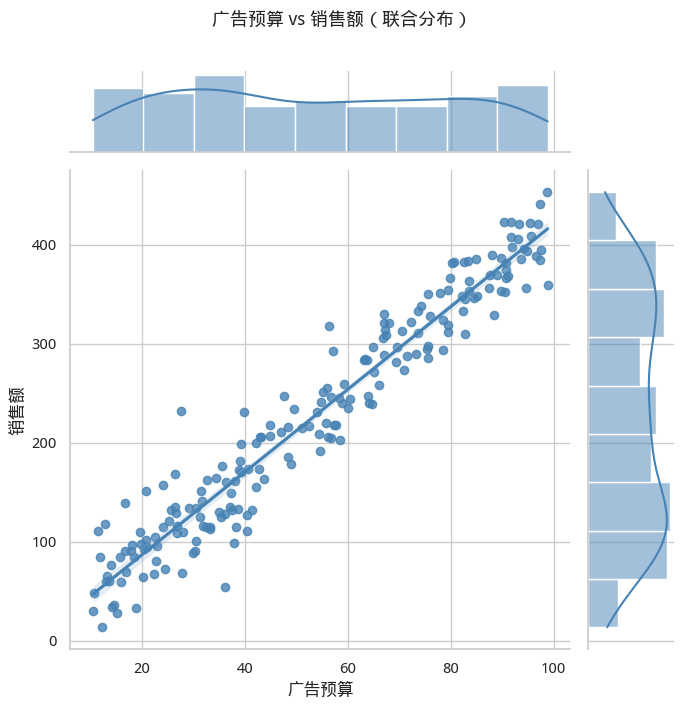

In [6]:
fig = sns.jointplot(
    data=df,
    x='广告预算',
    y='销售额',
    kind='reg',           # 'scatter', 'kde', 'hex', 'reg', 'resid'
    color='steelblue',
    height=7
)
fig.fig.suptitle('广告预算 vs 销售额（联合分布）', y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


`kind='hex'` 适合大数据量时避免过度绘制，`kind='kde'` 展示核密度联合分布。

---

## 五、🔧 综合实战：找出影响销量的关键因素

学了一堆理论，来个完整的实战练练手——把前面学的知识点串起来：


各因素与销量的相关系数：
广告预算     0.734
价格      -0.398
商品评分     0.364
促销力度     0.334
库存充足率    0.040
Name: 销量, dtype: float64


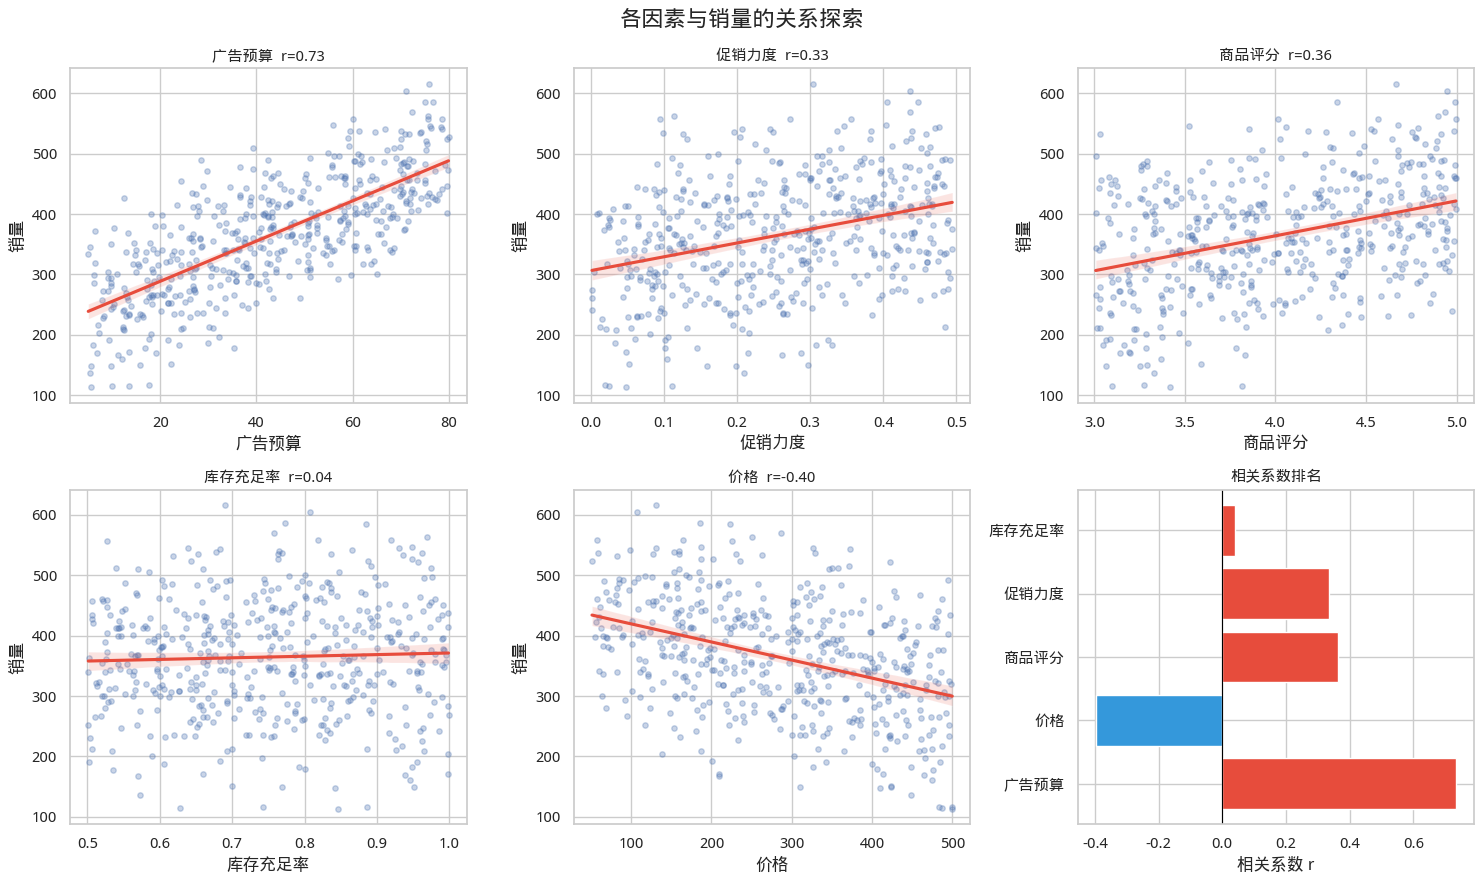

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

np.random.seed(2024)
n = 500

df = pd.DataFrame({
    '广告预算': np.random.uniform(5, 80, n),
    '促销力度': np.random.uniform(0, 0.5, n),
    '商品评分': np.random.uniform(3.0, 5.0, n),
    '库存充足率': np.random.uniform(0.5, 1.0, n),
    '价格':  np.random.uniform(50, 500, n)
})
df['销量'] = (
    df['广告预算'] * 3.2
    + df['促销力度'] * 200
    + df['商品评分'] * 50
    + df['库存充足率'] * 80
    - df['价格'] * 0.3
    + np.random.normal(0, 30, n)
).clip(10)

# ── 计算相关性 ──
corr_with_sales = df.corr()['销量'].drop('销量').sort_values(key=abs, ascending=False)
print("各因素与销量的相关系数：")
print(corr_with_sales.round(3))

# ── 可视化 ──
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flat

factors = ['广告预算', '促销力度', '商品评分', '库存充足率', '价格']
for i, factor in enumerate(factors):
    sns.regplot(data=df, x=factor, y='销量',
                 scatter_kws={'alpha': 0.3, 's': 15},
                 line_kws={'color': '#E74C3C'},
                 ax=axes[i])
    r = df[factor].corr(df['销量'])
    axes[i].set_title(f'{factor}  r={r:.2f}', fontweight='bold', fontsize=11)

# 最后一个子图：相关系数条形图
axes[5].barh(
    corr_with_sales.index,
    corr_with_sales.values,
    color=['#E74C3C' if v > 0 else '#3498DB' for v in corr_with_sales.values]
)
axes[5].axvline(x=0, color='black', linewidth=0.8)
axes[5].set_title('相关系数排名', fontweight='bold', fontsize=11)
axes[5].set_xlabel('相关系数 r')

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.suptitle('各因素与销量的关系探索', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


---

## 六、📋 图表选择速查

| 场景 | 推荐图 |
|------|--------|
| 两变量线性关系 | 散点图 + 回归线（`regplot`） |
| 两变量 + 第三变量 | 气泡图（大小/颜色编码） |
| 多变量全局相关 | 相关热力图（`heatmap`） |
| 两变量联合+边缘分布 | `jointplot` |
| 多变量两两关系 | `pairplot` |

---

## 七、📝 小结

关系探索的核心问题只有两个：
1. **两变量有没有关系**（看散点图形态）
2. **关系多强**（看相关系数 r）

r 的判断参考：

| r 绝对值 | 关系强度 |
|---------|---------|
| 0.8~1.0 | 强相关 |
| 0.5~0.8 | 中等相关 |
| 0.3~0.5 | 弱相关 |
| <0.3    | 几乎无相关 |

---

## 八、🏋️ 课后练习

1. 对你实战项目的数据，画 `广告预算 vs 销售额` 散点图，标注相关系数。
2. 用相关热力图找出所有变量中，对 `销售额` 影响最大的前 3 个因素。
3. 用 `jointplot(kind='kde')` 探索任意两个连续变量的联合分布形态。

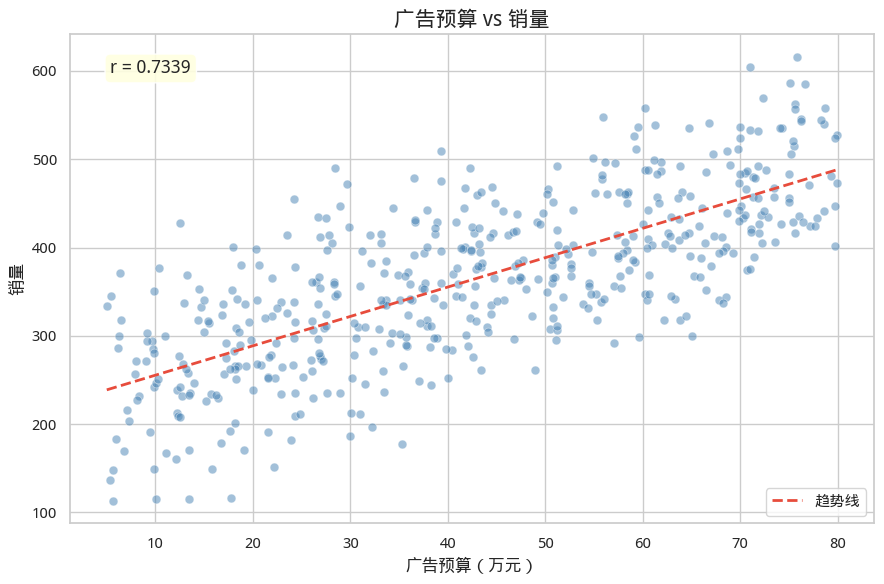

In [9]:
# ═══════════════════════════════════════════
# 练习1：广告预算 vs 销量 散点图，标注相关系数
# ═══════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(data=df, x='广告预算', y='销量',
                color='steelblue', alpha=0.5, s=40, ax=ax)

# 添加趋势线
z = np.polyfit(df['广告预算'], df['销量'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['广告预算'].min(), df['广告预算'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='#E74C3C', linewidth=2, label='趋势线')

# 标注相关系数
r = df['广告预算'].corr(df['销量'])
ax.text(0.05, 0.92, f'r = {r:.4f}', transform=ax.transAxes,
        fontsize=13, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

ax.set_title('广告预算 vs 销量', fontsize=15, fontweight='bold')
ax.set_xlabel('广告预算（万元）', fontsize=12)
ax.set_ylabel('销量', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('exercise1_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


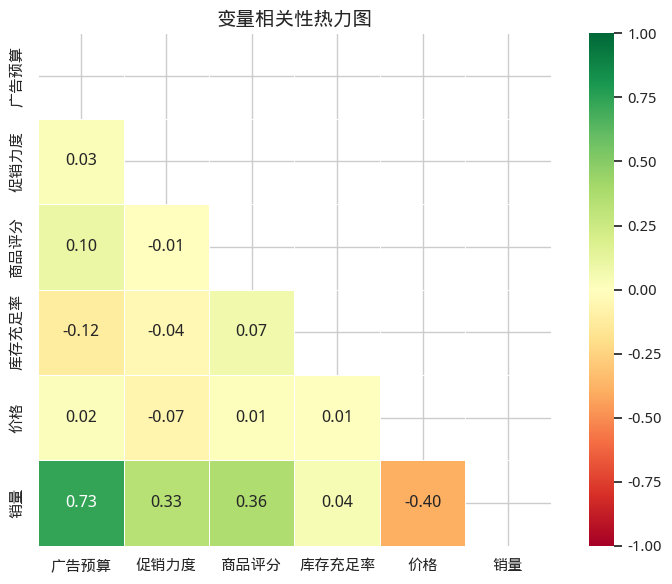

对销量影响最大的前3个因素：
  Top1：广告预算（r = 0.7339 ↑）
  Top2：价格（r = -0.3975 ↓）
  Top3：商品评分（r = 0.3642 ↑）


In [10]:
# ═══════════════════════════════════════════
# 练习2：相关热力图 → 找对销量影响最大的前3个因素
# ═══════════════════════════════════════════
corr = df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5, ax=ax)

ax.set_title('变量相关性热力图', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('exercise2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# 提取与销量相关性最高的前3个
top3 = corr['销量'].drop('销量').abs().sort_values(ascending=False).head(3)
print("对销量影响最大的前3个因素：")
for rank, (factor, r_val) in enumerate(top3.items(), 1):
    # 带符号的相关系数
    actual_r = corr.loc[factor, '销量']
    direction = '↑' if actual_r > 0 else '↓'
    print(f"  Top{rank}：{factor}（r = {actual_r:.4f} {direction}）")

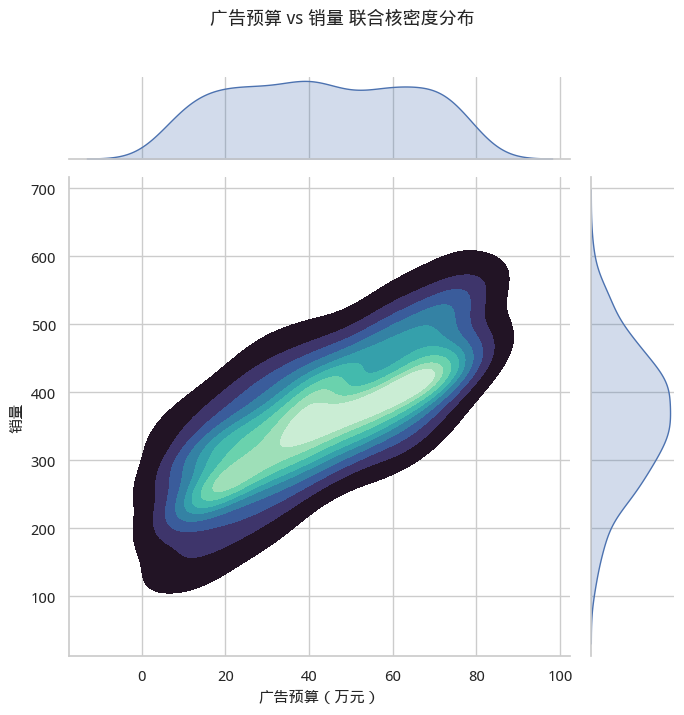

In [11]:
# ═══════════════════════════════════════════
# 练习3：jointplot(kind='kde') 探索联合分布
# ═══════════════════════════════════════════
# 选"广告预算"和"销量"这两个关系最密切的变量
g = sns.jointplot(data=df, x='广告预算', y='销量',
                  kind='kde',           # 核密度估计
                  fill=True,            # 填充颜色
                  cmap='mako',          # 配色
                  height=7,
                  thresh=0.05)

g.fig.suptitle('广告预算 vs 销量 联合核密度分布', y=1.02,
               fontsize=13, fontweight='bold')
g.ax_joint.set_xlabel('广告预算（万元）', fontsize=11)
g.ax_joint.set_ylabel('销量', fontsize=11)
plt.tight_layout()
plt.savefig('exercise3_kde.png', dpi=150, bbox_inches='tight')
plt.show()

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 25 篇：多子图布局与组合图表**
>
> 探索完单变量和双变量，下篇学多子图布局与组合图表——如何把多张图拼成一页仪表盘，一次呈现完整的分析故事。

---

*跟着小荷，数据分析路上不迷路～*